In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [5]:
df=pd.read_csv("CAR - CAR (1).csv")
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000.0,50000.0,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000.0,100000.0,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000.0,46000.0,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000.0,141000.0,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999.0,80000.0,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999.0,80000.0,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000.0,83000.0,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000.0,90000.0,Diesel,Individual,Manual,First Owner


In [6]:
df.isna().sum()

name             0
year             0
selling_price    1
km_driven        2
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [7]:
df['selling_price']=df['selling_price'].fillna(df['selling_price'].mean())
df['km_driven']=df['km_driven'].fillna(df['km_driven'].mean())

In [8]:
df.isna().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [9]:
df1=df[df['fuel']=='Petrol']

In [10]:
df2=df[df['owner']=='First Owner']

In [11]:
merge_p=pd.merge(df1,df2 ,on='year')

In [12]:
merge_p

,name_x,year,selling_price_x,km_driven_x,fuel_x,seller_type_x,transmission_x,owner_x,name_y,selling_price_y,km_driven_y,fuel_y,seller_type_y,transmission_y,owner_y
0,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner,Maruti 800 AC,60000.0,70000.0,Petrol,Individual,Manual,First Owner
1,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner,Maruti Wagon R LXI Minor,135000.0,50000.0,Petrol,Individual,Manual,First Owner
2,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner,Maruti Alto LX BSIII,140000.0,125000.0,Petrol,Individual,Manual,First Owner
3,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner,Maruti 800 AC,60000.0,70000.0,Petrol,Individual,Manual,First Owner
4,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner,Maruti Wagon R LXI Minor,135000.0,50000.0,Petrol,Individual,Manual,First Owner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443842,Renault KWID RXT,2016,225000.0,40000.0,Petrol,Individual,Manual,First Owner,Ford Endeavour 3.2 Titanium AT 4X4,1800000.0,126000.0,Diesel,Dealer,Automatic,First Owner
443843,Renault KWID RXT,2016,225000.0,40000.0,Petrol,Individual,Manual,First Owner,Maruti Swift VDI,630000.0,55000.0,Diesel,Dealer,Manual,First Owner
443844,Renault KWID RXT,2016,225000.0,40000.0,Petrol,Individual,Manual,First Owner,Maruti Swift VDI,630000.0,55000.0,Diesel,Dealer,Manual,First Owner
443845,Renault KWID RXT,2016,225000.0,40000.0,Petrol,Individual,Manual,First Owner,Hyundai Creta 1.6 CRDi SX Option,865000.0,90000.0,Diesel,Individual,Manual,First Owner


In [13]:
df.describe


<bound method NDFrame.describe of                                      name  year  selling_price  km_driven  \
0                           Maruti 800 AC  2007        60000.0    70000.0   
1                Maruti Wagon R LXI Minor  2007       135000.0    50000.0   
2                    Hyundai Verna 1.6 SX  2012       600000.0   100000.0   
3                  Datsun RediGO T Option  2017       250000.0    46000.0   
4                   Honda Amaze VX i-DTEC  2014       450000.0   141000.0   
...                                   ...   ...            ...        ...   
4335  Hyundai i20 Magna 1.4 CRDi (Diesel)  2014       409999.0    80000.0   
4336           Hyundai i20 Magna 1.4 CRDi  2014       409999.0    80000.0   
4337                  Maruti 800 AC BSIII  2009       110000.0    83000.0   
4338     Hyundai Creta 1.6 CRDi SX Option  2016       865000.0    90000.0   
4339                     Renault KWID RXT  2016       225000.0    40000.0   

        fuel seller_type transmission    

In [14]:
df['fuel']=df['fuel'].map({'Petrol':0,'Diesel':2,'CNG':3,'LPG':3,'Electric':4})
df['seller_type']=df['seller_type'].map({'Individual':0,'Dealer':1,'Trustmark Dealer':2})
df['transmission']=df['transmission'].map({'Manual':0,'Automatic':1})
df['owner']=df['owner'].map({'First Owner':0,'Second Owner':1,'Third Owner':2,'Fourth & Above Owner':3,'Test Drive Car':4})

In [15]:
df = df[df['selling_price'] > 0]
df = df[df['km_driven'] > 0]

In [16]:
df.describe()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner
count,4340.000000,4.340000e+03,4340.000000,4340.000000,4340.000000,4340.000000,4340.00000
mean,2013.090783,5.042205e+05,66243.652374,1.036636,0.276037,0.103226,0.46659
std,4.215344,5.785162e+05,46625.916804,1.021905,0.496892,0.304289,0.74033
min,1992.000000,2.000000e+04,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2011.000000,2.100000e+05,35000.000000,0.000000,0.000000,0.000000,0.00000
50%,2014.000000,3.500000e+05,60000.000000,2.000000,0.000000,0.000000,0.00000
75%,2016.000000,6.000000e+05,90000.000000,2.000000,1.000000,0.000000,1.00000
max,2020.000000,8.900000e+06,806599.000000,4.000000,2.000000,1.000000,4.00000


In [17]:
x_uni=df[['km_driven']]
y=df['selling_price']


In [18]:
x_trainu,x_testu,y_trainu,y_testu=train_test_split(x_uni,y,test_size=0.2,random_state=1)


In [19]:
modelu=LinearRegression()
modelu.fit(x_trainu,y_trainu)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
y_predu=modelu.predict(x_testu)
mean_squared_error(y_testu,y_predu)


293179533137.1676

In [21]:
r2_score(y_testu,y_predu)

0.03163051465460942

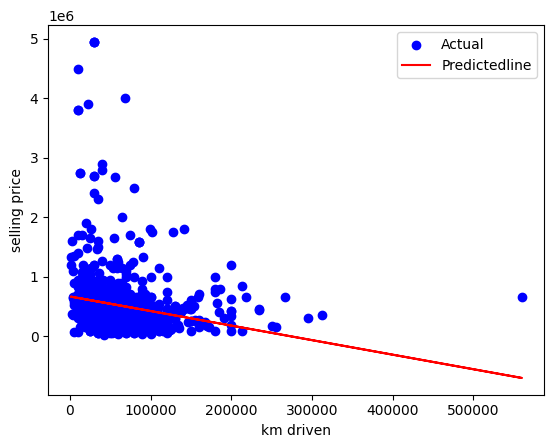

In [22]:
plt.scatter(x_testu,y_testu,color='blue',label='Actual')
plt.plot(x_testu,y_predu,color='red',label='Predictedline')
plt.xlabel('km driven')
plt.ylabel('selling price')
plt.legend()
plt.show()


In [23]:
user_km =float(input('enter km'))
predicted=modelu.predict([[user_km]])
predicted[0]

enter km 8000


C:\Users\Sanika\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(647108.2045505606)

In [24]:
print(df['km_driven'].min())
print(df['km_driven'].max())

1.0
806599.0


In [25]:
x=df.drop(columns=['name','selling_price'])
y=df['selling_price']

In [26]:
x_trainm,x_testm,y_trainm,y_testm=train_test_split(x,y,test_size=0.2,random_state=1)

In [29]:
modelm=LinearRegression()
modelm.fit(x_trainm,y_trainm)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
y_predm=modelm.predict(x_testm)

In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_testm, y_predm)

mae = mean_absolute_error(y_testm, y_predm)

r2 = r2_score(y_testm, y_predm)

print("Mean Squared Error:", mse)

print("Mean Absolute Error:", mae)

print("R2 Score:", r2)

Mean Squared Error: 153087594225.81528
Mean Absolute Error: 223487.5395461164
R2 Score: 0.49435298826313934


In [40]:
print("\n--- Predict Price (Multivariate) ---")

year = int(input("Enter Year (e.g., 2015): "))
km = float(input("Enter KM Driven: "))
fuel = int(input("Fuel (Petrol:0, Diesel:1, CNG:2, LPG:3): "))
seller = int(input("Seller (Individual:0, Dealer:1): "))
trans = int(input("Transmission (Manual:0, Auto:1): "))
owner = int(input("Owner (First:0, Second:1, Third:2): "))

user_data = [[year, km, fuel, seller, trans, owner]]

predicted_m = modelm.predict(user_data)

print("Predicted Selling Price:", max(0,predicted_m[0]))


--- Predict Price (Multivariate) ---


Enter Year (e.g., 2015):  2020
Enter KM Driven:  30000
Fuel (Petrol:0, Diesel:1, CNG:2, LPG:3):  0
Seller (Individual:0, Dealer:1):  0
Transmission (Manual:0, Auto:1):  1
Owner (First:0, Second:1, Third:2):  2


Predicted Selling Price: 1349848.6982741803


C:\Users\Sanika\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


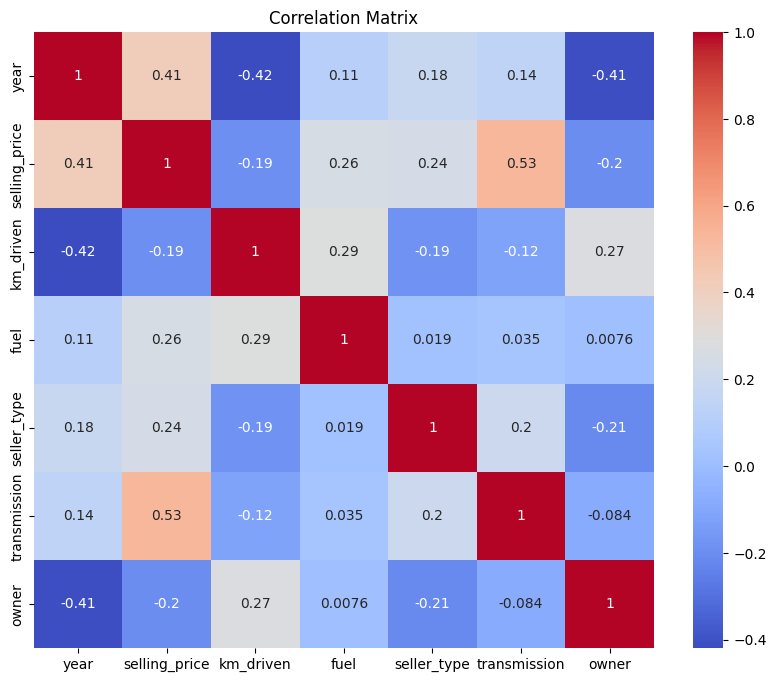

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()